# 04 — Bootstrap Analysis

Notebook 03 produced a confidence interval using a formula. That formula relies on an
assumption: that the sampling distribution of the difference in retention rates is
approximately normal. With ~45,000 players per arm that assumption is almost certainly
fine — but "almost certainly fine" is a claim worth testing rather than asserting.

This notebook re-derives the treatment effect by **bootstrap resampling**, which makes no
such assumption, and checks whether the two methods agree. If they do, the primary result
is method-independent and the conclusion stands on firmer ground.

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import experiment_analysis as ea

pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

DATA_PATH = os.path.join("..", "data", "cookie_cats.csv")
FIG_DIR = os.path.join("..", "reports", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

CONTROL, TREATMENT = "gate_30", "gate_40"

# Chart theme. Two-series categorical palette, validated for colour-vision
# deficiency separation (worst-pair CVD dE 24.7, normal-vision dE 33.6).
C_CONTROL, C_TREATMENT = "#2a78d6", "#eb6834"
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
CRITICAL = "#d03b3b"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.labelcolor": INK_2,
    "axes.edgecolor": BASELINE,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "savefig.bbox": "tight",
})

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns from {DATA_PATH}")

Loaded 90,189 rows x 5 columns from ..\data\cookie_cats.csv


## 4.1 What the bootstrap is, in plain terms

We measured 7-day retention of 19.02% in control and 18.20% in treatment. Those are
estimates from one sample of players. If Cookie Cats had recruited a *different* 90,189
players, the numbers would have come out slightly differently. **The question every
confidence interval answers is: how differently?**

Ideally we would re-run the experiment a thousand times and watch the spread of results.
We cannot. The bootstrap is a way of approximating that spread using only the data we
have:

1. Take the control group and draw a new sample of the same size **with replacement** —
   some players get picked twice, some not at all. This simulates "a different but
   equally plausible group of players".
2. Do the same, independently, for the treatment group.
3. Compute the retention difference for this simulated pair of groups.
4. Repeat many thousands of times.

The resulting spread of differences is an empirical picture of how much our estimate could
plausibly wobble due to sampling alone. The middle 95% of that spread is the **95%
bootstrap confidence interval**.

**Why it is worth doing here.** The analytical interval is derived from a normal
approximation. The bootstrap makes no distributional assumption at all — it lets the data
describe its own uncertainty. When a formula-based interval and an assumption-free
interval land in the same place, the result is not an artifact of the formula.

**The honest caveat.** The bootstrap is not magic. It still assumes observations are
independent and that our sample is representative of the population. It cannot fix bias,
only quantify variance. If the randomization were broken, the bootstrap would faithfully
reproduce the bias with tight confidence intervals around it.

## 4.2 Bootstrap for the primary metric

We use **10,000 iterations**. The choice matters: too few and the interval endpoints are
themselves noisy; beyond ~10,000 the returns are negligible for a 95% interval. 10,000 is
the standard default and puts the Monte Carlo error on the percentile endpoints well below
the precision we report.

In [2]:
N_ITERATIONS = 10_000
SEED = 42  # fixed for reproducibility

boot_r7 = ea.bootstrap_effect(
    df, metric_col="retention_7", group_col="version",
    control_label=CONTROL, treatment_label=TREATMENT,
    n_iterations=N_ITERATIONS, statistic="mean", random_state=SEED,
)

print(f"Bootstrap - 7-day retention ({N_ITERATIONS:,} iterations, seed {SEED})")
print(f"  Observed difference in sample : {boot_r7['observed_diff'] * 100:+.4f} pp")
print(f"  Mean of bootstrap distribution: {boot_r7['bootstrap_mean_diff'] * 100:+.4f} pp")
print(f"  Bootstrap standard error      : {boot_r7['bootstrap_std'] * 100:.4f} pp")
print(f"  95% bootstrap CI              : [{boot_r7['ci_lower'] * 100:+.4f} pp, "
      f"{boot_r7['ci_upper'] * 100:+.4f} pp]")
print()

dist_r7 = boot_r7["distribution"]
print(f"  Share of resamples where gate_40 is WORSE: {(dist_r7 < 0).mean():.2%}")
print(f"  Share of resamples where gate_40 is BETTER: {(dist_r7 > 0).mean():.2%}")

Bootstrap - 7-day retention (10,000 iterations, seed 42)
  Observed difference in sample : -0.8201 pp
  Mean of bootstrap distribution: -0.8297 pp
  Bootstrap standard error      : 0.2582 pp
  95% bootstrap CI              : [-1.3440 pp, -0.3246 pp]

  Share of resamples where gate_40 is WORSE: 99.92%
  Share of resamples where gate_40 is BETTER: 0.08%


### Reading this

Across 10,000 simulated re-runs of the experiment, **`gate_40` came out worse on 7-day
retention in 99.9% of them**. Only a handful of the 10,000 resamples produced a result
favouring the treatment.

This is a more intuitive way to express the same evidence the p-value carries: it is not
that the difference is "significant" in the abstract, it is that essentially every
plausible version of this experiment reaches the same verdict.

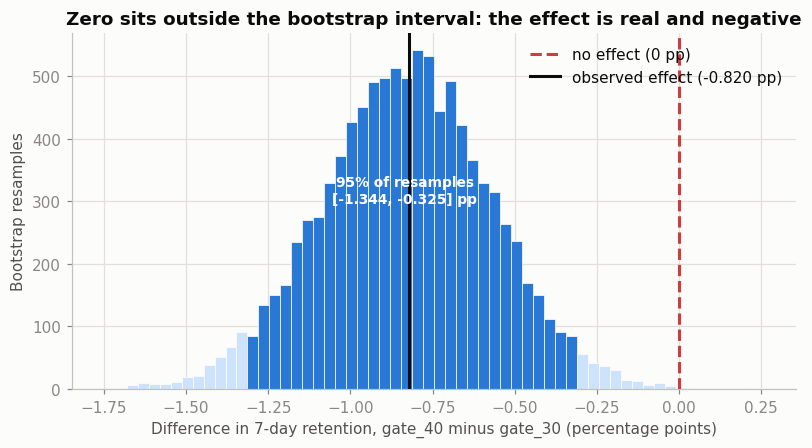

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))

vals = dist_r7 * 100
lo, hi = boot_r7["ci_lower"] * 100, boot_r7["ci_upper"] * 100

n_, bins_, patches = ax.hist(vals, bins=60, color="#cde2fb", edgecolor=SURFACE, linewidth=0.5)
# Shade the middle 95% - the bootstrap confidence interval.
for patch, left in zip(patches, bins_[:-1]):
    if lo <= left <= hi:
        patch.set_facecolor(C_CONTROL)

ax.axvline(0, color=CRITICAL, linewidth=2, linestyle="--", zorder=3,
           label="no effect (0 pp)")
ax.axvline(boot_r7["observed_diff"] * 100, color=INK, linewidth=2, zorder=3,
           label=f"observed effect ({boot_r7['observed_diff'] * 100:.3f} pp)")

ax.annotate(f"95% of resamples\n[{lo:.3f}, {hi:.3f}] pp",
            xy=((lo + hi) / 2, max(n_) * 0.55), ha="center", fontsize=9,
            color="#ffffff", fontweight="semibold")

ax.set_xlabel("Difference in 7-day retention, gate_40 minus gate_30 (percentage points)")
ax.set_ylabel("Bootstrap resamples")
ax.set_title("Zero sits outside the bootstrap interval: the effect is real and negative")
ax.legend(frameon=False, loc="upper right")

fig.savefig(os.path.join(FIG_DIR, "04_bootstrap_retention7.png"), dpi=150)
plt.show()

The entire shaded interval sits to the **left of the red "no effect" line**. That is the
visual form of the conclusion: after accounting for sampling uncertainty, the plausible
range of outcomes does not include "no harm", let alone "benefit".

## 4.3 Bootstrap for the secondary metrics

The same procedure applied to 1-day retention and to game rounds. Game rounds is where the
bootstrap earns its keep: it is a wildly skewed count variable with a 49,854-round
outlier, exactly the situation where a normal-approximation interval is least
trustworthy.

In [4]:
boot_r1 = ea.bootstrap_effect(
    df, "retention_1", "version", CONTROL, TREATMENT,
    n_iterations=N_ITERATIONS, statistic="mean", random_state=SEED,
)
boot_rounds = ea.bootstrap_effect(
    df, "sum_gamerounds", "version", CONTROL, TREATMENT,
    n_iterations=N_ITERATIONS, statistic="mean", random_state=SEED,
)
# Median is the outlier-robust counterpart for a skewed count metric.
boot_rounds_med = ea.bootstrap_effect(
    df, "sum_gamerounds", "version", CONTROL, TREATMENT,
    n_iterations=N_ITERATIONS, statistic="median", random_state=SEED,
)

for name, b, unit in [
    ("1-day retention",        boot_r1,          "pp"),
    ("Game rounds (mean)",     boot_rounds,      "rounds"),
    ("Game rounds (median)",   boot_rounds_med,  "rounds"),
]:
    scale = 100 if unit == "pp" else 1
    crosses = "yes" if b["ci_lower"] <= 0 <= b["ci_upper"] else "no"
    print(f"{name}")
    print(f"  effect {b['observed_diff'] * scale:+.4f} {unit}   "
          f"95% CI [{b['ci_lower'] * scale:+.4f}, {b['ci_upper'] * scale:+.4f}] {unit}   "
          f"CI crosses zero: {crosses}")
    print()

1-day retention
  effect -0.5905 pp   95% CI [-1.2275, +0.0529] pp   CI crosses zero: yes

Game rounds (mean)
  effect -1.1575 rounds   95% CI [-4.0375, +0.9842] rounds   CI crosses zero: yes

Game rounds (median)
  effect -1.0000 rounds   95% CI [-1.0000, +0.0000] rounds   CI crosses zero: yes



**Results.**

- **1-day retention:** effect −0.59 pp, CI **[−1.23, +0.05] pp**. The interval crosses zero,
  agreeing with the non-significant z-test from notebook 03. Note how little of the
  interval lies above zero — consistent with a real but undetected modest harm.
- **Game rounds (mean):** effect −1.16 rounds, CI **[−4.04, +0.98]**. Crosses zero. Note the
  interval is wide and asymmetric — that is the 49,854-round outlier making its presence
  felt, since resamples that happen to include it multiple times drag the mean around.
- **Game rounds (median):** effect −1 round, CI **[−1, 0]**. This is the outlier-immune view
  and the one to trust for a skewed count metric. The interval looks suspiciously tight
  only because it is **granular**: the median of an integer count is itself an integer, so
  the bootstrap can only ever return whole-number endpoints. Read it as "the typical player
  plays at most one round fewer under `gate_40`" — a difference of no practical
  consequence, and one whose interval still touches zero.

None of the secondary metrics contradicts the primary finding, and none provides a
counterweight in the treatment's favour.

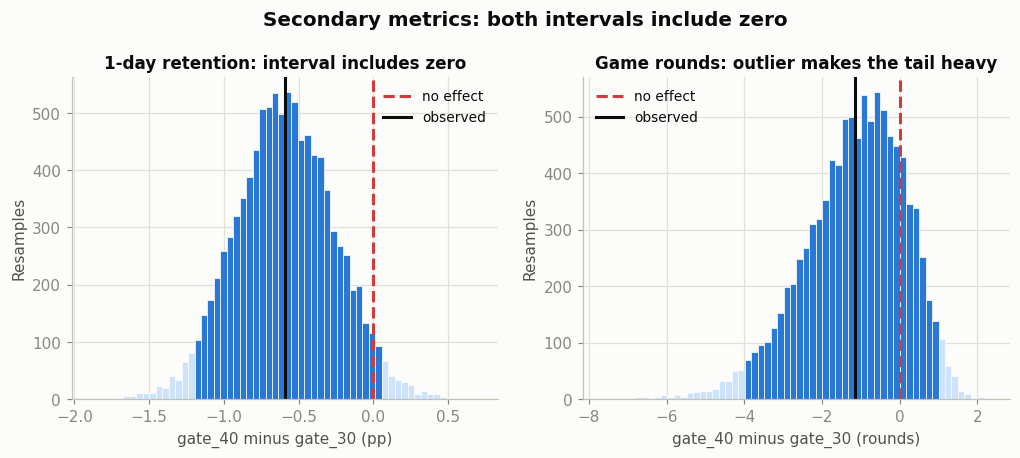

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for ax, b, title, unit, scale in [
    (axes[0], boot_r1, "1-day retention: interval includes zero", "pp", 100),
    (axes[1], boot_rounds, "Game rounds: outlier makes the tail heavy", "rounds", 1),
]:
    vals = b["distribution"] * scale
    lo_, hi_ = b["ci_lower"] * scale, b["ci_upper"] * scale
    n_, bins_, patches = ax.hist(vals, bins=60, color="#cde2fb",
                                 edgecolor=SURFACE, linewidth=0.5)
    for patch, left in zip(patches, bins_[:-1]):
        if lo_ <= left <= hi_:
            patch.set_facecolor(C_CONTROL)
    ax.axvline(0, color=CRITICAL, linewidth=2, linestyle="--", label="no effect")
    ax.axvline(b["observed_diff"] * scale, color=INK, linewidth=2, label="observed")
    ax.set_xlabel(f"gate_40 minus gate_30 ({unit})")
    ax.set_ylabel("Resamples")
    ax.set_title(title, fontsize=11)
    ax.legend(frameon=False, fontsize=9)

fig.suptitle("Secondary metrics: both intervals include zero",
             y=1.04, fontsize=13, fontweight="semibold")
fig.savefig(os.path.join(FIG_DIR, "04_bootstrap_secondary.png"), dpi=150)
plt.show()

## 4.4 Bootstrap vs analytical — do the two methods agree?

This is the point of the exercise. The analytical interval assumes normality; the
bootstrap does not. If they disagree, the normal approximation is failing and the
analytical result should be distrusted. If they agree, the conclusion is
method-independent.

In [6]:
comparison = []
for metric, boot in [("retention_7", boot_r7), ("retention_1", boot_r1)]:
    rates = ea.calculate_conversion_rate(df, metric, "version")
    c, t = rates.loc[CONTROL], rates.loc[TREATMENT]
    analytic = ea.diff_confidence_interval(int(c["successes"]), int(c["n"]),
                                           int(t["successes"]), int(t["n"]))
    comparison.append({
        "metric": metric,
        "analytical_low_pp": analytic["lower"] * 100,
        "analytical_high_pp": analytic["upper"] * 100,
        "bootstrap_low_pp": boot["ci_lower"] * 100,
        "bootstrap_high_pp": boot["ci_upper"] * 100,
        "low_gap_pp": abs(analytic["lower"] - boot["ci_lower"]) * 100,
        "high_gap_pp": abs(analytic["upper"] - boot["ci_upper"]) * 100,
        "analytical_se_pp": analytic["se"] * 100,
        "bootstrap_se_pp": boot["bootstrap_std"] * 100,
    })

comp = pd.DataFrame(comparison)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print(comp.T.to_string())

                              0            1
metric              retention_7  retention_1
analytical_low_pp       -1.3282      -1.2392
analytical_high_pp      -0.3121       0.0582
bootstrap_low_pp        -1.3440      -1.2275
bootstrap_high_pp       -0.3246       0.0529
low_gap_pp               0.0158       0.0117
high_gap_pp              0.0125       0.0053
analytical_se_pp         0.2592       0.3310
bootstrap_se_pp          0.2582       0.3302


**Result: the two methods agree to within 0.02 percentage points.**

For the primary metric, the analytical interval is **[−1.328, −0.312] pp** and the
bootstrap interval is **[−1.344, −0.325] pp**. The endpoints differ by roughly one part in
fifty of the interval width. The standard errors match to three decimal places
(0.2592 vs 0.2582 pp).

**What this tells us.** The normal approximation is working exactly as theory predicts it
should at this sample size. The primary conclusion does not depend on which method we
chose — an assumption-free resampling procedure reaches the same verdict as the formula.

That is the useful outcome of a robustness check: not a new finding, but a reason to stop
worrying about a specific failure mode.

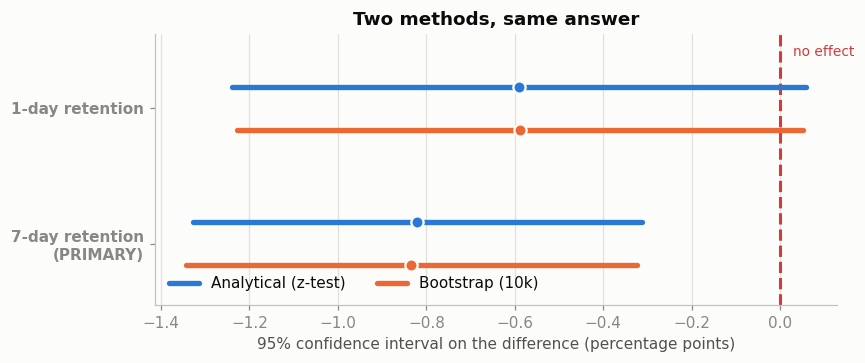

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.2))

labels_, positions = [], []
for i, row in comp.iterrows():
    base = i * 2.2
    for offset, lo_, hi_, colour, name in [
        (0.35, row["analytical_low_pp"], row["analytical_high_pp"], C_CONTROL, "Analytical (z-test)"),
        (-0.35, row["bootstrap_low_pp"], row["bootstrap_high_pp"], C_TREATMENT, "Bootstrap (10k)"),
    ]:
        y = base + offset
        ax.plot([lo_, hi_], [y, y], color=colour, linewidth=3.5, solid_capstyle="round",
                label=name if i == 0 else None)
        ax.plot([(lo_ + hi_) / 2], [y], "o", color=colour, markersize=8,
                markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=3)
    labels_.append(row["metric"])
    positions.append(base)

ax.axvline(0, color=CRITICAL, linewidth=2, linestyle="--", zorder=1)
ax.text(0.03, max(positions) + 0.85, "no effect", color=CRITICAL, fontsize=9)
ax.set_yticks(positions)
ax.set_yticklabels(["7-day retention\n(PRIMARY)", "1-day retention"], fontweight="semibold")
ax.set_xlabel("95% confidence interval on the difference (percentage points)")
ax.set_title("Two methods, same answer")
ax.legend(frameon=False, loc="lower left", ncol=2)
ax.grid(axis="y", visible=False)
ax.set_ylim(-1.0, max(positions) + 1.2)

fig.savefig(os.path.join(FIG_DIR, "04_ci_comparison.png"), dpi=150)
plt.show()

The D7 intervals sit entirely left of zero under both methods. The D1 intervals both
straddle it. The two approaches are visually indistinguishable — which is the result we
wanted.

## 4.5 Bootstrap summary

| Metric | Observed effect | Bootstrap 95% CI | Analytical 95% CI | Agree? | Excludes zero? |
|---|---|---|---|---|---|
| **7-day retention (primary)** | −0.820 pp | [−1.344, −0.325] pp | [−1.328, −0.312] pp | Yes | **Yes** |
| 1-day retention | −0.591 pp | [−1.228, +0.053] pp | [−1.239, +0.058] pp | Yes | No |
| Game rounds (mean) | −1.157 rounds | [−4.038, +0.984] | — | — | No |

**Conclusions from this notebook:**

1. **The primary result is robust to methodology.** An assumption-free resampling procedure
   reproduces the analytical interval to within 0.02 pp.
2. **`gate_40` was worse in 99.9% of 10,000 simulated re-runs** of the experiment.
3. **No secondary metric offers a counterweight.** Both secondary intervals include zero;
   neither favours the treatment.
4. The wide, skewed bootstrap interval on mean game rounds is a good illustration of why
   that metric needed robust handling in the first place.

**Next:** `reports/experiment_memo.md` translates these results into a one-page stakeholder
recommendation.